# 14 · Explaining models: SHAP, permutation importance and partial dependence

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/14_explainability_shap.ipynb)

A bank cannot deploy a credit model it cannot explain. Regulators require *reason codes* for declined applicants,
risk committees want to know what drives the model, and you need to catch models that learned something silly.

You will explain a gradient-boosting default model **globally** (what matters overall), **locally** (why *this*
applicant got *this* score), and use explanations to **catch a leak**.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
import warnings; warnings.filterwarnings("ignore")
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=True)
    import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

cr = pd.read_csv(DATA + "credit_default.csv")
X = pd.get_dummies(cr.drop(columns="default"), columns=["purpose"], drop_first=True, dtype=float)
y = cr["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0).fit(X_train, y_train)
print("shap", shap.__version__, "| test AUC", round(roc_auc_score(y_test, gbm.predict_proba(X_test)[:, 1]), 3))

shap 0.51.0 | test AUC 0.777


## 1. Global view #1: permutation importance
Shuffle one column at a time in the **test** set and measure how much AUC drops. Model-agnostic and honest, but it only says *how much* a feature matters, not *in which direction*.

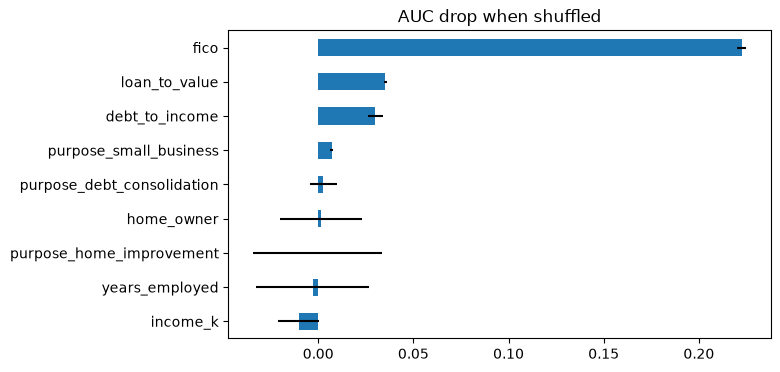

In [3]:
pi = permutation_importance(gbm, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=0)
pd.Series(pi.importances_mean, index=X.columns).sort_values().plot.barh(xerr=pi.importances_std, figsize=(7, 4), title="AUC drop when shuffled")
plt.show()

## 2. SHAP values: a fair split of each prediction
SHAP comes from game theory (Shapley values): treat the features as players who together produce the prediction,
and give each one its average marginal contribution across all orders in which features could be added.
The key property is **additivity**:

$$\text{prediction}_i = \text{base value} + \sum_j \text{SHAP}_{ij}$$

For a gradient-boosting classifier the prediction is in **log-odds**. `TreeExplainer` computes exact SHAP values for tree models quickly.

In [4]:
explainer = shap.TreeExplainer(gbm)
sv = explainer(X_test)                       # an Explanation object: .values, .base_values, .data
print("SHAP matrix:", sv.values.shape, "| base value (average log-odds):", np.round(np.ravel(sv.base_values)[0], 3))

SHAP matrix: (200, 9) | base value (average log-odds): -2.127


### Exercise 1

Verify additivity. For every test applicant compute `base value + sum of SHAP values` and compare it with the model’s log-odds `gbm.decision_function(X_test)`. Store the largest absolute difference in `additivity_gap`.

<details><summary>Hint</summary>

`np.abs(np.ravel(sv.base_values) + sv.values.sum(axis=1) - gbm.decision_function(X_test)).max()`

</details>

In [5]:
# Your code here

In [6]:
check("14.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 14.1: not answered yet. Store your answer in `additivity_gap`.


## 3. Global view #2: the beeswarm plot
Each dot is one applicant. Position = SHAP value (push toward default to the right). Colour = feature value (red high, blue low). You see importance **and** direction **and** non-linearity in one picture.

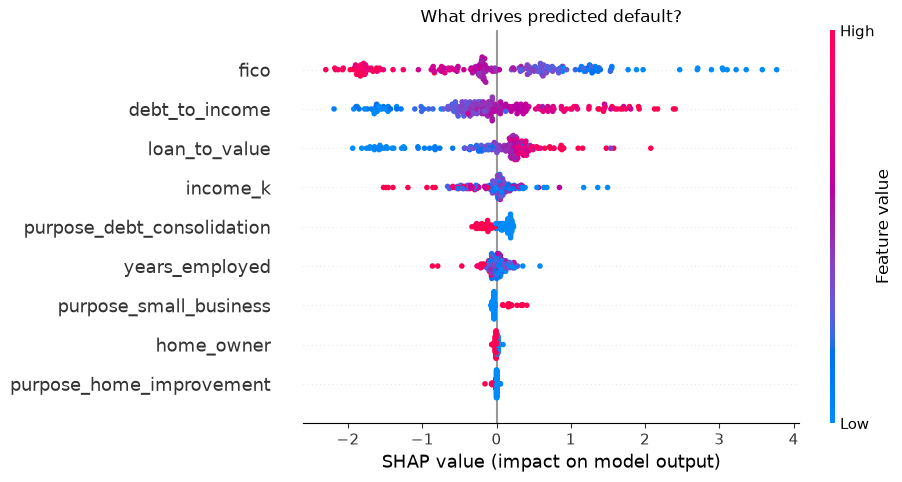

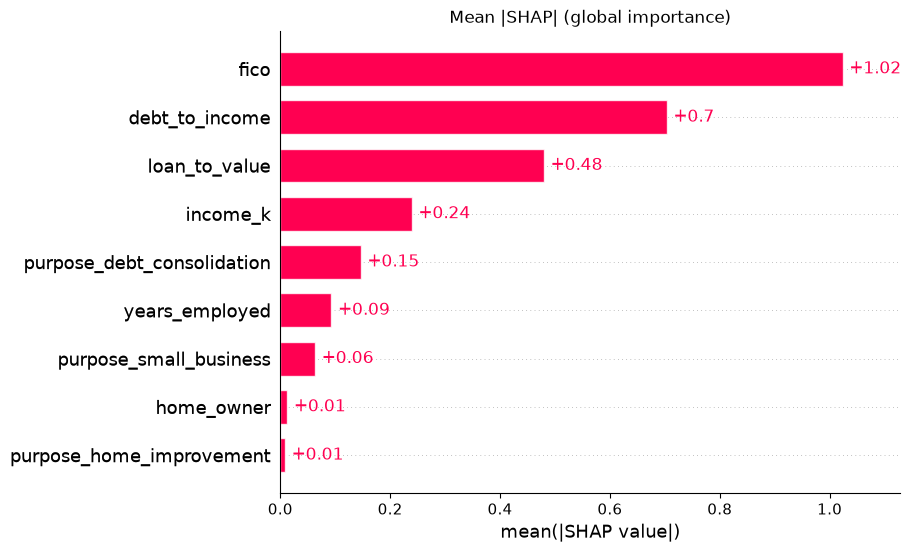

In [7]:
shap.plots.beeswarm(sv, max_display=10, show=False); plt.title("What drives predicted default?"); plt.show()
shap.plots.bar(sv, max_display=10, show=False); plt.title("Mean |SHAP| (global importance)"); plt.show()

## 4. How does one feature act? SHAP dependence vs partial dependence
The data were built with a non-linear debt-to-income effect. Can the explanations find it?

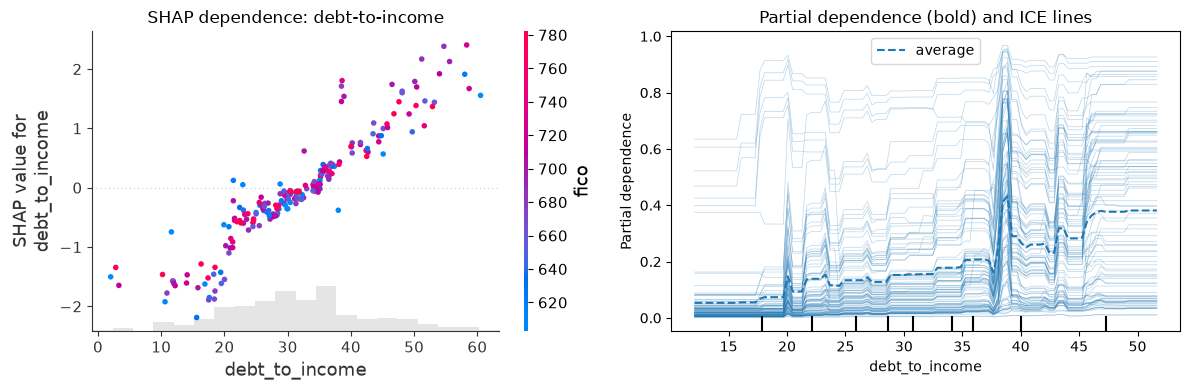

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
shap.plots.scatter(sv[:, "debt_to_income"], color=sv[:, "fico"], ax=ax[0], show=False); ax[0].set_title("SHAP dependence: debt-to-income")
PartialDependenceDisplay.from_estimator(gbm, X_test, ["debt_to_income"], kind="both", subsample=100, random_state=0, ax=ax[1])
ax[1].set_title("Partial dependence (bold) and ICE lines"); plt.tight_layout(); plt.show()

The effect gets steeper at high debt-to-income: a curve a linear model could not capture. The colour shows FICO interacting with it.

## 5. Local explanations: reason codes for one declined applicant

Applicant at test position 23: predicted default probability 95.0%
income_k                       27.7
debt_to_income                 60.5
fico                          585.0
loan_to_value                  64.1
years_employed                  6.3
home_owner                      1.0
purpose_debt_consolidation      1.0
purpose_home_improvement        0.0
purpose_small_business          0.0


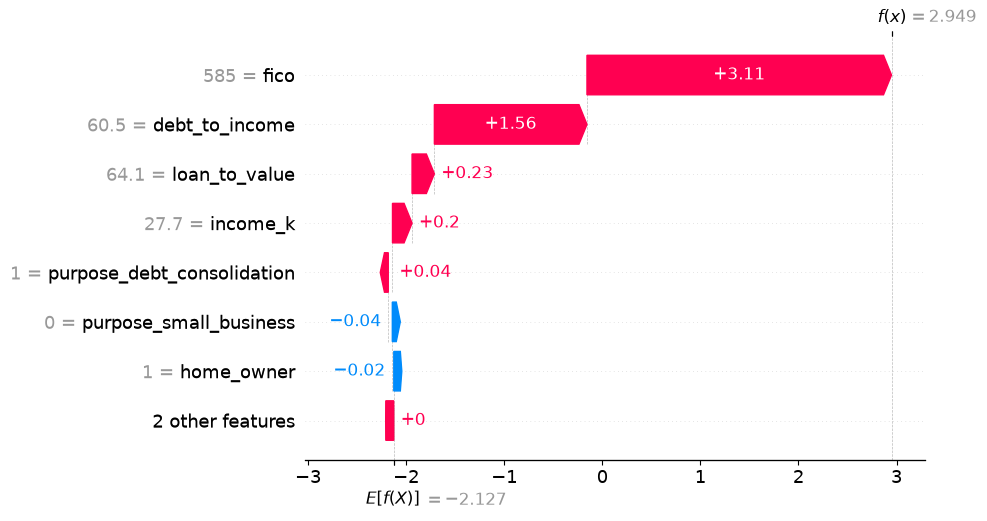

In [9]:
pd_test = gbm.predict_proba(X_test)[:, 1]
i = int(np.argmax(pd_test))                                  # the riskiest applicant in the test set
print(f"Applicant at test position {i}: predicted default probability {pd_test[i]:.1%}")
print(X_test.iloc[i].round(2).to_string())
shap.plots.waterfall(sv[i], max_display=8, show=False); plt.show()

### Exercise 2

For that same applicant (`i`), find the feature with the **largest positive** SHAP value (the main reason for the high score). Store its column name as a string in `top_reason`.

<details><summary>Hint</summary>

`X_test.columns[np.argmax(sv.values[i])]`

</details>

In [10]:
# Your code here

In [11]:
check("14.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 14.2: not answered yet. Store your answer in `top_reason`.


In [12]:
def reason_codes(row_idx, k=3):
    s = pd.Series(sv.values[row_idx], index=X.columns).sort_values(ascending=False)
    return [f"{f} = {X_test.iloc[row_idx][f]:.4g} (+{v:.2f} log-odds)" for f, v in s.head(k).items() if v > 0]
print("Top reasons for the decision:"); print("\n".join(" • " + r for r in reason_codes(i)))

Top reasons for the decision:
 • fico = 585 (+3.11 log-odds)
 • debt_to_income = 60.5 (+1.56 log-odds)
 • loan_to_value = 64.1 (+0.23 log-odds)


## 6. A linear model, explained the same way
For logistic regression with independent features, SHAP values are simply coefficient × (value − average): the explanation methods agree with what you already know.

In [13]:
sc = StandardScaler().fit(X_train)
lr = LogisticRegression(max_iter=2000).fit(sc.transform(X_train), y_train)
lin_exp = shap.LinearExplainer(lr, shap.maskers.Independent(sc.transform(X_train), max_samples=len(X_train)))
sv_lin = lin_exp(sc.transform(X_test))
manual = lr.coef_[0] * (sc.transform(X_test) - sc.transform(X_train).mean(0))
print("max difference between SHAP and coef × (x − mean):", float(np.abs(sv_lin.values - manual).max()))

max difference between SHAP and coef × (x − mean): 0.0


## 7. Use explanations to catch a leak
Rebuild the leaky model from notebook 10 (it used a field that only exists after default). One glance at SHAP exposes it.

Leaky model test AUC: 0.97


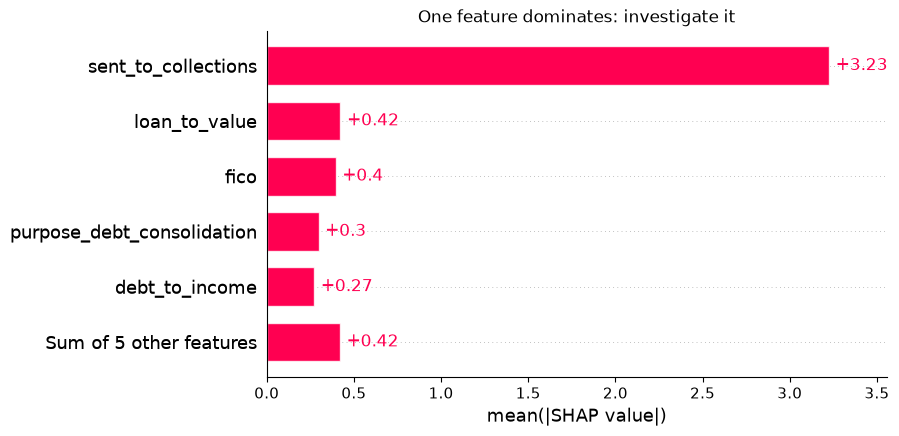

In [14]:
rng = np.random.default_rng(1)
X_leak = X.copy()
X_leak["sent_to_collections"] = ((y == 1) & (rng.random(len(y)) < 0.9)).astype(float)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_leak, y, test_size=0.25, random_state=0, stratify=y)
leaky = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0).fit(Xl_tr, yl_tr)
sv_leak = shap.TreeExplainer(leaky)(Xl_te)
print("Leaky model test AUC:", round(roc_auc_score(yl_te, leaky.predict_proba(Xl_te)[:, 1]), 3))
shap.plots.bar(sv_leak, max_display=6, show=False); plt.title("One feature dominates: investigate it"); plt.show()

### Exercise 3

Store the name of the feature with the highest mean |SHAP| in the leaky model in `leak_feature`.

<details><summary>Hint</summary>

`X_leak.columns[np.abs(sv_leak.values).mean(0).argmax()]`

</details>

In [15]:
# Your code here

In [16]:
check("14.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 14.3: not answered yet. Store your answer in `leak_feature`.


## 8. What SHAP does **not** tell you
- **It explains the model, not the world.** A large SHAP value is not a causal effect; change the feature in reality and the outcome may not follow.
- **Correlated features share credit unpredictably.** If two features carry the same information, the split between them can be arbitrary.
- **Background data matters.** The base value and the explanations depend on the reference population.
- **Explanations can be gamed.** A model can look sensible on average while discriminating locally; also check performance and outcomes across groups.

## 9. A one-page model card (fill it in for your own models)
| Section | Content |
|---|---|
| Purpose | Predict 12-month default probability for consumer loan applications |
| Data | 800 loans, features …, target …, period …, known gaps |
| Performance | Test AUC, calibration, performance by segment |
| Main drivers | Top SHAP features and their direction |
| Limitations | Population it was trained on, features excluded on purpose, drift risks |
| Monitoring | What is tracked monthly and the thresholds that trigger a review |

---
## Solutions

In [17]:
additivity_gap = np.abs(np.ravel(sv.base_values) + sv.values.sum(axis=1) - gbm.decision_function(X_test)).max()
print("1) largest additivity gap:", additivity_gap)
top_reason = X_test.columns[np.argmax(sv.values[i])]; print("2) main reason:", top_reason)
leak_feature = X_leak.columns[np.abs(sv_leak.values).mean(0).argmax()]; print("3) leaky feature:", leak_feature)
check_all("14")

1) largest additivity gap: 7.993605777301127e-15
2) main reason: fico
3) leaky feature: sent_to_collections
✅ Exercise 14.1: correct.


✅ Exercise 14.2: correct.
✅ Exercise 14.3: correct.

3 of 3 exercises correct.
